In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import importlib
import subprocess
import sys
from pathlib import Path


def ensure_package(pkg_name, import_name=None):
    import_name = import_name or pkg_name
    try:
        importlib.import_module(import_name)
        print(f'{pkg_name}: already installed')
    except Exception:
        print(f'Installing {pkg_name} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg_name])


ensure_package('ultralytics')
ensure_package('pyyaml', 'yaml')
ensure_package('matplotlib')
ensure_package('pillow', 'PIL')
ensure_package('numpy')



Installing ultralytics ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.9 MB/s eta 0:00:00
pyyaml: already installed
matplotlib: already installed
pillow: already installed
numpy: already installed


In [3]:
from pathlib import Path
import random
import shutil
import yaml
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Rectangle
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
RUNS_DIR = PROJECT_ROOT / 'runs' / 'detect'
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Working directory: {PROJECT_ROOT}')
print(f'Runs directory: {RUNS_DIR}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Working directory: /kaggle/working
Runs directory: /kaggle/working/runs/detect


In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="0J6knQgEjJOEscjo74FN")
project = rf.workspace("workspace-1-myjxi").project("acne-detection-cbm6h")
version = project.version(1)
dataset = version.download("yolov11")
                

loading Roboflow workspace...
loading Roboflow project...


In [6]:
from pathlib import Path
import yaml

# your dataset path
dataset_path = Path("acne-detection-1")  # adjust if needed

data_yaml_path = dataset_path / "data.yaml"

with open(data_yaml_path, "r") as f:
    data = yaml.safe_load(f)

print("Classes:", data["names"])
print("Number of classes:", data["nc"])

Classes: ['Acne', 'Dark Circles', 'Englarged Pores', 'Wrinkles']
Number of classes: 4


In [8]:
from pathlib import Path
import shutil
import yaml

SRC_ROOT = Path("acne-detection-1")
DST_ROOT = Path("acne-only-dataset")

splits = ["train", "valid", "test"]

for split in splits:
    img_dir = SRC_ROOT / split / "images"
    lbl_dir = SRC_ROOT / split / "labels"

    if not img_dir.exists():
        continue

    out_img_dir = DST_ROOT / split / "images"
    out_lbl_dir = DST_ROOT / split / "labels"
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    for img_path in img_dir.iterdir():
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
            continue

        label_path = lbl_dir / f"{img_path.stem}.txt"
        kept_lines = []

        if label_path.exists():
            with open(label_path, "r", encoding="utf-8") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5 and parts[0] == "0":   # keep Acne only
                        kept_lines.append(line.strip())

        shutil.copy2(img_path, out_img_dir / img_path.name)

        with open(out_lbl_dir / f"{img_path.stem}.txt", "w", encoding="utf-8") as f:
            f.write("\n".join(kept_lines))

new_yaml = {
    "path": str(DST_ROOT.resolve()),
    "train": "train/images",
    "val": "valid/images",
    "names": ["acne"],
    "nc": 1
}

if (DST_ROOT / "test" / "images").exists():
    new_yaml["test"] = "test/images"

with open(DST_ROOT / "data.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump(new_yaml, f, sort_keys=False)

print("Created acne-only dataset at:", DST_ROOT)
print(yaml.safe_dump(new_yaml, sort_keys=False))

Created acne-only dataset at: acne-only-dataset
path: /kaggle/working/acne-only-dataset
train: train/images
val: valid/images
names:
- acne
nc: 1
test: test/images



In [9]:
from pathlib import Path

label_dir = Path("/kaggle/working/acne-only-dataset/train/labels")

total_files = 0
non_empty = 0
total_boxes = 0

for f in label_dir.glob("*.txt"):
    total_files += 1
    text = f.read_text().strip()
    if text:
        non_empty += 1
        total_boxes += len(text.splitlines())

print("Total images:", total_files)
print("Images with acne:", non_empty)
print("Total acne boxes:", total_boxes)

Total images: 494
Images with acne: 444
Total acne boxes: 2145


In [14]:
from pathlib import Path

root = Path("/kaggle/working/merged-acne-dataset")

for split in ["train", "valid", "test"]:
    lbl_dir = root / split / "labels"
    if not lbl_dir.exists():
        continue

    total_files = 0
    non_empty = 0
    total_boxes = 0

    for f in lbl_dir.glob("*.txt"):
        total_files += 1
        text = f.read_text(encoding="utf-8").strip()
        if text:
            non_empty += 1
            total_boxes += len(text.splitlines())

    print(f"{split}:")
    print("  label files:", total_files)
    print("  images with acne:", non_empty)
    print("  acne boxes:", total_boxes)

train:
  label files: 494
  images with acne: 444
  acne boxes: 2145
valid:
  label files: 136
  images with acne: 122
  acne boxes: 582
test:
  label files: 76
  images with acne: 68
  acne boxes: 350


In [15]:
import os
from pathlib import Path

for p in Path("/kaggle/working/merged-acne-dataset").rglob("*.cache"):
    os.remove(p)
    print("Deleted", p)

In [16]:
from pathlib import Path
import random
import shutil
import os
import yaml

random.seed(42)

SRC_ROOT = Path("/kaggle/working/merged-acne-dataset")
DST_ROOT = Path("/kaggle/working/merged-acne-dataset-resplit")

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# collect all image-label pairs from all existing splits
all_samples = []

for split in ["train", "valid", "test"]:
    img_dir = SRC_ROOT / split / "images"
    lbl_dir = SRC_ROOT / split / "labels"

    if not img_dir.exists():
        continue

    for img_path in img_dir.iterdir():
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue

        lbl_path = lbl_dir / f"{img_path.stem}.txt"

        # keep image even if label is empty, but label file should exist
        if lbl_path.exists():
            all_samples.append((img_path, lbl_path))
        else:
            # create a temporary empty label entry if needed
            all_samples.append((img_path, None))

print("Total samples found:", len(all_samples))

# shuffle once
random.shuffle(all_samples)

# new ratios
train_ratio = 0.70
valid_ratio = 0.15
test_ratio = 0.15

n = len(all_samples)
train_end = int(n * train_ratio)
valid_end = int(n * (train_ratio + valid_ratio))

train_data = all_samples[:train_end]
valid_data = all_samples[train_end:valid_end]
test_data  = all_samples[valid_end:]

print("Train:", len(train_data))
print("Valid:", len(valid_data))
print("Test:", len(test_data))

# remove destination if it already exists
if DST_ROOT.exists():
    shutil.rmtree(DST_ROOT)

# create folders
for split in ["train", "valid", "test"]:
    (DST_ROOT / split / "images").mkdir(parents=True, exist_ok=True)
    (DST_ROOT / split / "labels").mkdir(parents=True, exist_ok=True)

def copy_split(data, split_name):
    for img_path, lbl_path in data:
        dst_img = DST_ROOT / split_name / "images" / img_path.name
        dst_lbl = DST_ROOT / split_name / "labels" / f"{img_path.stem}.txt"

        shutil.copy2(img_path, dst_img)

        if lbl_path is not None and lbl_path.exists():
            shutil.copy2(lbl_path, dst_lbl)
        else:
            dst_lbl.write_text("", encoding="utf-8")

copy_split(train_data, "train")
copy_split(valid_data, "valid")
copy_split(test_data, "test")

# write yaml
data_yaml = {
    "path": str(DST_ROOT),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": ["acne"],
    "nc": 1,
}

with open(DST_ROOT / "data.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(f"Resplit dataset created at: {DST_ROOT}")
print(yaml.safe_dump(data_yaml, sort_keys=False))

Total samples found: 706
Train: 494
Valid: 106
Test: 106
Resplit dataset created at: /kaggle/working/merged-acne-dataset-resplit
path: /kaggle/working/merged-acne-dataset-resplit
train: train/images
val: valid/images
test: test/images
names:
- acne
nc: 1



In [17]:
from pathlib import Path

root = Path("/kaggle/working/merged-acne-dataset-resplit")

for split in ["train", "valid", "test"]:
    img_dir = root / split / "images"
    lbl_dir = root / split / "labels"

    print(f"\nChecking {split}...")
    print("Image dir exists:", img_dir.exists())
    print("Label dir exists:", lbl_dir.exists())

    if not img_dir.exists() or not lbl_dir.exists():
        print(f"Missing folder in {split}, skipping")
        continue

    n_imgs = len([p for p in img_dir.iterdir() if p.is_file()])
    n_lbls = len(list(lbl_dir.glob("*.txt")))

    total_boxes = 0
    non_empty = 0
    for lf in lbl_dir.glob("*.txt"):
        text = lf.read_text(encoding="utf-8").strip()
        if text:
            non_empty += 1
            total_boxes += len(text.splitlines())

    print("images =", n_imgs)
    print("labels =", n_lbls)
    print("images with acne =", non_empty)
    print("acne boxes =", total_boxes)


Checking train...
Image dir exists: True
Label dir exists: True
images = 494
labels = 494
images with acne = 440
acne boxes = 2108

Checking valid...
Image dir exists: True
Label dir exists: True
images = 106
labels = 106
images with acne = 95
acne boxes = 434

Checking test...
Image dir exists: True
Label dir exists: True
images = 106
labels = 106
images with acne = 99
acne boxes = 535


In [18]:
from pathlib import Path

root = Path("/kaggle/working/merged-acne-dataset-resplit")

for split in ["train", "valid", "test"]:
    img_dir = root / split / "images"
    lbl_dir = root / split / "labels"
    if not img_dir.exists():
        continue

    missing_labels = []
    for img_path in img_dir.iterdir():
        if img_path.is_file():
            lbl_path = lbl_dir / f"{img_path.stem}.txt"
            if not lbl_path.exists():
                missing_labels.append(img_path.name)

    print(split, "missing labels:", len(missing_labels))

train missing labels: 0
valid missing labels: 0
test missing labels: 0


In [20]:
import yaml
from pathlib import Path

# ✅ Set your dataset path directly
DATASET_ROOT = Path("/kaggle/working/merged-acne-dataset-resplit")

data_yaml_path = DATASET_ROOT / "data.yaml"

yaml_dict = {
    'path': str(DATASET_ROOT),
    'train': 'train/images',
    'val': 'valid/images',   # ✅ explicitly correct
    'test': 'test/images',   # ✅ you have test split
    'names': ['acne'],
    'nc': 1,
}

with open(data_yaml_path, 'w', encoding='utf-8') as f:
    yaml.safe_dump(yaml_dict, f, sort_keys=False)

print(f'Wrote YAML: {data_yaml_path}')
print(yaml.safe_dump(yaml_dict, sort_keys=False))

Wrote YAML: /kaggle/working/merged-acne-dataset-resplit/data.yaml
path: /kaggle/working/merged-acne-dataset-resplit
train: train/images
val: valid/images
test: test/images
names:
- acne
nc: 1



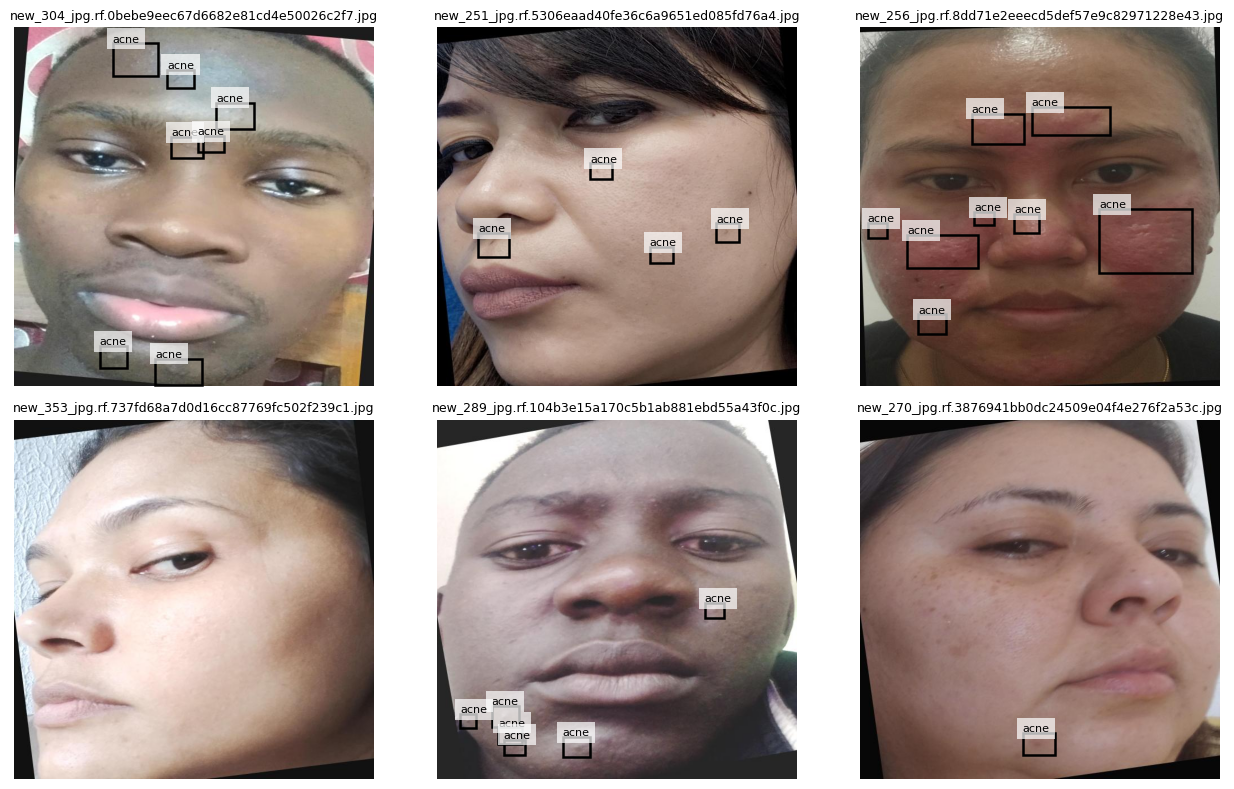

In [21]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Rectangle

# Use your merged dataset
DATASET_ROOT = Path("/kaggle/working/merged-acne-dataset-resplit")

def list_images(folder):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return [p for p in folder.iterdir() if p.suffix.lower() in exts]

def draw_yolo_boxes(ax, img_w, img_h, label_path):
    if not label_path.exists():
        return

    text = label_path.read_text(encoding="utf-8").strip()
    if not text:
        return

    for line in text.splitlines():
        parts = line.split()
        if len(parts) != 5:
            continue

        cls_id, xc, yc, bw, bh = parts
        xc, yc, bw, bh = map(float, [xc, yc, bw, bh])

        box_w = bw * img_w
        box_h = bh * img_h
        x0 = (xc * img_w) - box_w / 2
        y0 = (yc * img_h) - box_h / 2

        rect = Rectangle((x0, y0), box_w, box_h, fill=False, linewidth=1.8)
        ax.add_patch(rect)

        ax.text(
            x0,
            max(y0 - 3, 0),
            "acne",
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

train_images = list_images(DATASET_ROOT / "train" / "images")
sample_n = min(6, len(train_images))
show_images = random.sample(train_images, sample_n)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for i, img_path in enumerate(show_images):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    ax = axes[i]
    ax.imshow(img)

    label_path = DATASET_ROOT / "train" / "labels" / f"{img_path.stem}.txt"
    draw_yolo_boxes(ax, w, h, label_path)

    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

augmentation and tighten dataset boxes 


In [23]:
import cv2
import shutil
import yaml
from pathlib import Path
from tqdm import tqdm
import albumentations as A

# =========================
# PATHS
# =========================
DATASET_ROOT = Path("/kaggle/working/merged-acne-dataset-resplit")
OUT_ROOT = Path("/kaggle/working/acne-augmented-map5095")

AUG_PER_IMAGE = 2

# =========================
# CREATE OUTPUT DATASET
# =========================
if OUT_ROOT.exists():
    shutil.rmtree(OUT_ROOT)

for split in ["train", "valid", "test"]:
    (OUT_ROOT / split / "images").mkdir(parents=True, exist_ok=True)
    (OUT_ROOT / split / "labels").mkdir(parents=True, exist_ok=True)

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# =========================
# AUGMENTATION PIPELINE
# =========================
transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),

        A.Affine(
            scale=(0.90, 1.10),
            translate_percent=(-0.04, 0.04),
            rotate=(-8, 8),
            shear=(-3, 3),
            p=0.6
        ),

        A.RandomBrightnessContrast(
            brightness_limit=0.18,
            contrast_limit=0.18,
            p=0.5
        ),

        A.HueSaturationValue(
            hue_shift_limit=4,
            sat_shift_limit=12,
            val_shift_limit=12,
            p=0.35
        ),

        A.GaussianBlur(
            blur_limit=(3, 5),
            p=0.15
        ),

        A.ImageCompression(
            quality_range=(75, 100),
            p=0.25
        ),
    ],
    bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
        min_visibility=0.35
    )
)

# =========================
# HELPER FUNCTIONS
# =========================
def read_yolo_labels(label_path):
    boxes = []
    class_labels = []

    if not label_path.exists():
        return boxes, class_labels

    text = label_path.read_text().strip()
    if not text:
        return boxes, class_labels

    for line in text.splitlines():
        parts = line.split()

        if len(parts) != 5:
            continue

        cls, xc, yc, w, h = parts

        boxes.append([
            float(xc),
            float(yc),
            float(w),
            float(h)
        ])

        class_labels.append(int(float(cls)))

    return boxes, class_labels


def save_yolo_labels(label_path, boxes, class_labels):
    with open(label_path, "w") as f:
        for cls, box in zip(class_labels, boxes):
            xc, yc, w, h = box
            f.write(f"{cls} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")

# =========================
# COPY VALID AND TEST ONLY
# =========================
for split in ["valid", "test"]:
    img_dir = DATASET_ROOT / split / "images"
    label_dir = DATASET_ROOT / split / "labels"

    for img_path in img_dir.iterdir():
        if img_path.suffix.lower() not in image_exts:
            continue

        label_path = label_dir / f"{img_path.stem}.txt"

        shutil.copy(
            img_path,
            OUT_ROOT / split / "images" / img_path.name
        )

        out_label_path = OUT_ROOT / split / "labels" / f"{img_path.stem}.txt"

        if label_path.exists():
            shutil.copy(label_path, out_label_path)
        else:
            out_label_path.write_text("")

# =========================
# COPY + AUGMENT TRAIN
# =========================
train_img_dir = DATASET_ROOT / "train" / "images"
train_label_dir = DATASET_ROOT / "train" / "labels"

train_images = [
    p for p in train_img_dir.iterdir()
    if p.suffix.lower() in image_exts
]

for img_path in tqdm(train_images):
    label_path = train_label_dir / f"{img_path.stem}.txt"

    image = cv2.imread(str(img_path))

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    boxes, class_labels = read_yolo_labels(label_path)

    # Save original image
    shutil.copy(
        img_path,
        OUT_ROOT / "train" / "images" / img_path.name
    )

    # Save original label
    out_label_path = OUT_ROOT / "train" / "labels" / f"{img_path.stem}.txt"

    if label_path.exists():
        shutil.copy(label_path, out_label_path)
    else:
        out_label_path.write_text("")

    # If image has no boxes, do not augment
    if len(boxes) == 0:
        continue

    # Create augmented versions
    for i in range(AUG_PER_IMAGE):
        aug = transform(
            image=image,
            bboxes=boxes,
            class_labels=class_labels
        )

        aug_image = aug["image"]
        aug_boxes = aug["bboxes"]
        aug_classes = aug["class_labels"]

        if len(aug_boxes) == 0:
            continue

        new_stem = f"{img_path.stem}_aug{i}"

        new_img_path = OUT_ROOT / "train" / "images" / f"{new_stem}.jpg"
        new_label_path = OUT_ROOT / "train" / "labels" / f"{new_stem}.txt"

        aug_image_bgr = cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR)

        cv2.imwrite(str(new_img_path), aug_image_bgr)

        save_yolo_labels(
            new_label_path,
            aug_boxes,
            aug_classes
        )

# =========================
# CREATE DATA.YAML
# =========================
data_yaml = {
    "path": str(OUT_ROOT),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 1,
    "names": ["acne"]
}

with open(OUT_ROOT / "data.yaml", "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("Augmented dataset created at:", OUT_ROOT)
print("YAML file created at:", OUT_ROOT / "data.yaml")

# =========================
# CHECK COUNTS
# =========================
for split in ["train", "valid", "test"]:
    imgs = list((OUT_ROOT / split / "images").glob("*"))
    labels = list((OUT_ROOT / split / "labels").glob("*.txt"))

    print(split)
    print("images:", len(imgs))
    print("labels:", len(labels))
    print()

100%|██████████| 494/494 [00:09<00:00, 54.74it/s]

Augmented dataset created at: /kaggle/working/acne-augmented-map5095
YAML file created at: /kaggle/working/acne-augmented-map5095/data.yaml
train
images: 1374
labels: 1374

valid
images: 106
labels: 106

test
images: 106
labels: 106



training with the dataset t

training with the augmented dataset 

In [25]:
from pathlib import Path
from ultralytics import YOLO

# Use the AUGMENTED dataset YAML
DATA_YAML_PATH = Path("/kaggle/working/acne-augmented-map5095/data.yaml")
RUNS_DIR = Path("/kaggle/working/runs")

model = YOLO("yolov8m.pt")

train_results = model.train(
    data=str(DATA_YAML_PATH),
    epochs=100,
    imgsz=1024,
    batch=16,
    optimizer="AdamW",
    lr0=3e-4,
    lrf=0.01,
    weight_decay=5e-4,
    warmup_epochs=3,
    single_cls=True,
    patience=20,
    workers=2,
    cache=False,
    project=str(RUNS_DIR),
    name="acne_aug_map5095",
    exist_ok=True,
    plots=True,
    pretrained=True,
    close_mosaic=10
)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/acne-augmented-map5095/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=acne_aug_map5095, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW

In [26]:
import csv
import shutil
from pathlib import Path
import matplotlib.pyplot as plt

# Set paths for your current run
RUNS_DIR = Path("/kaggle/working/runs")
run_name = "acne_only_debug"
PROJECT_ROOT = Path("/kaggle/working")

run_dir = RUNS_DIR / run_name
results_csv = run_dir / "results.csv"

metrics_dir = PROJECT_ROOT / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

if not results_csv.exists():
    print(f"results.csv not found yet at: {results_csv}")
    print("Run the training cell successfully first.")
else:
    rows_epoch = []
    with open(results_csv, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows_epoch.append(r)

    # Save a copy
    epoch_csv_copy = metrics_dir / "training_epoch_metrics.csv"
    shutil.copy2(results_csv, epoch_csv_copy)
    print(f"Saved epoch metrics copy: {epoch_csv_copy}")

    # Read metrics
    x = [int(float(r["epoch"])) for r in rows_epoch]
    p = [float(r.get("metrics/precision(B)", 0.0)) for r in rows_epoch]
    rc = [float(r.get("metrics/recall(B)", 0.0)) for r in rows_epoch]
    m50 = [float(r.get("metrics/mAP50(B)", 0.0)) for r in rows_epoch]
    m5095 = [float(r.get("metrics/mAP50-95(B)", 0.0)) for r in rows_epoch]

    # Print final epoch metrics
    last = rows_epoch[-1]
    print("\nFinal epoch metrics:")
    print(f"Epoch:      {last['epoch']}")
    print(f"Precision:  {float(last.get('metrics/precision(B)', 0.0)):.4f}")
    print(f"Recall:     {float(last.get('metrics/recall(B)', 0.0)):.4f}")
    print(f"mAP50:      {float(last.get('metrics/mAP50(B)', 0.0)):.4f}")
    print(f"mAP50-95:   {float(last.get('metrics/mAP50-95(B)', 0.0)):.4f}")

    # Find best epoch by mAP50
    best_row = max(rows_epoch, key=lambda r: float(r.get("metrics/mAP50(B)", 0.0)))
    print("\nBest epoch by mAP50:")
    print(f"Epoch:      {best_row['epoch']}")
    print(f"Precision:  {float(best_row.get('metrics/precision(B)', 0.0)):.4f}")
    print(f"Recall:     {float(best_row.get('metrics/recall(B)', 0.0)):.4f}")
    print(f"mAP50:      {float(best_row.get('metrics/mAP50(B)', 0.0)):.4f}")
    print(f"mAP50-95:   {float(best_row.get('metrics/mAP50-95(B)', 0.0)):.4f}")

    # Plot metrics
    plt.figure(figsize=(10, 5))
    plt.plot(x, p, label="Precision")
    plt.plot(x, rc, label="Recall")
    plt.plot(x, m50, label="mAP50")
    plt.plot(x, m5095, label="mAP50-95")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Training Metrics by Epoch")
    plt.legend()
    plt.tight_layout()

    epoch_plot = metrics_dir / "training_metrics_by_epoch.png"
    plt.savefig(epoch_plot, dpi=160)
    plt.show()
    print(f"Saved: {epoch_plot}")

results.csv not found yet at: /kaggle/working/runs/acne_only_debug/results.csv
Run the training cell successfully first.


Saved epoch metrics copy: /kaggle/working/metrics/training_epoch_metrics_acne_aug_map5095.csv

Final epoch metrics:
Epoch:      100
Precision:  0.9626
Recall:     0.8825
mAP50:      0.9103
mAP50-95:   0.7030

Best epoch by mAP50-95:
Epoch:      100
Precision:  0.9626
Recall:     0.8825
mAP50:      0.9103
mAP50-95:   0.7030


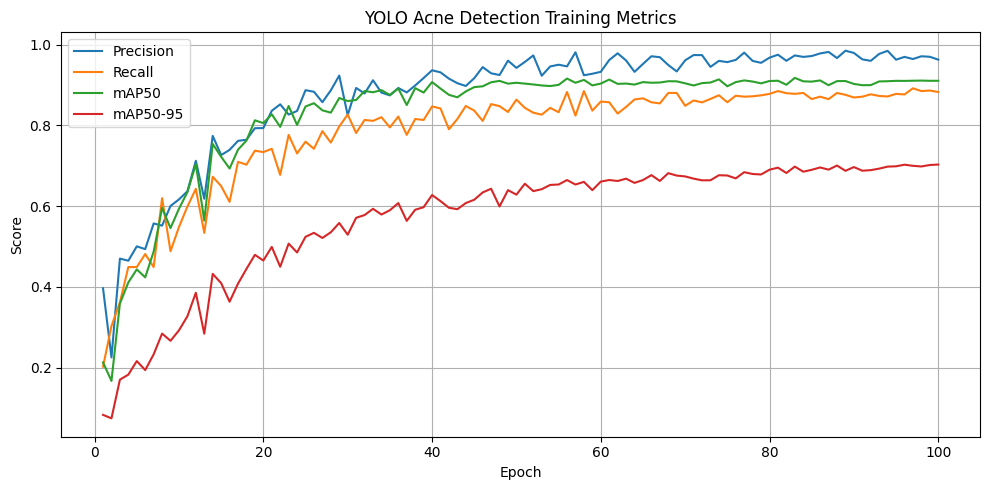

Saved plot: /kaggle/working/metrics/training_metrics_acne_aug_map5095.png


In [27]:
import csv
import shutil
from pathlib import Path
import matplotlib.pyplot as plt

# Correct path for your current run
RUNS_DIR = Path("/kaggle/working/runs")
run_name = "acne_aug_map5095"

PROJECT_ROOT = Path("/kaggle/working")

run_dir = RUNS_DIR / run_name
results_csv = run_dir / "results.csv"

metrics_dir = PROJECT_ROOT / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

if not results_csv.exists():
    print(f"results.csv not found at: {results_csv}")
    print("Check your run folder name.")
else:
    rows_epoch = []

    with open(results_csv, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows_epoch.append(r)

    # Save copy
    epoch_csv_copy = metrics_dir / "training_epoch_metrics_acne_aug_map5095.csv"
    shutil.copy2(results_csv, epoch_csv_copy)

    print(f"Saved epoch metrics copy: {epoch_csv_copy}")

    # Extract metrics
    x = [int(float(r["epoch"])) for r in rows_epoch]

    p = [float(r["metrics/precision(B)"]) for r in rows_epoch]
    rc = [float(r["metrics/recall(B)"]) for r in rows_epoch]
    m50 = [float(r["metrics/mAP50(B)"]) for r in rows_epoch]
    m5095 = [float(r["metrics/mAP50-95(B)"]) for r in rows_epoch]

    # Final epoch metrics
    last = rows_epoch[-1]

    print("\nFinal epoch metrics:")
    print(f"Epoch:      {last['epoch']}")
    print(f"Precision:  {float(last['metrics/precision(B)']):.4f}")
    print(f"Recall:     {float(last['metrics/recall(B)']):.4f}")
    print(f"mAP50:      {float(last['metrics/mAP50(B)']):.4f}")
    print(f"mAP50-95:   {float(last['metrics/mAP50-95(B)']):.4f}")

    # Best epoch by mAP50-95
    best_row = max(
        rows_epoch,
        key=lambda r: float(r["metrics/mAP50-95(B)"])
    )

    print("\nBest epoch by mAP50-95:")
    print(f"Epoch:      {best_row['epoch']}")
    print(f"Precision:  {float(best_row['metrics/precision(B)']):.4f}")
    print(f"Recall:     {float(best_row['metrics/recall(B)']):.4f}")
    print(f"mAP50:      {float(best_row['metrics/mAP50(B)']):.4f}")
    print(f"mAP50-95:   {float(best_row['metrics/mAP50-95(B)']):.4f}")

    # Plot metrics
    plt.figure(figsize=(10, 5))
    plt.plot(x, p, label="Precision")
    plt.plot(x, rc, label="Recall")
    plt.plot(x, m50, label="mAP50")
    plt.plot(x, m5095, label="mAP50-95")

    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("YOLO Acne Detection Training Metrics")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    epoch_plot = metrics_dir / "training_metrics_acne_aug_map5095.png"
    plt.savefig(epoch_plot, dpi=160)
    plt.show()

    print(f"Saved plot: {epoch_plot}")

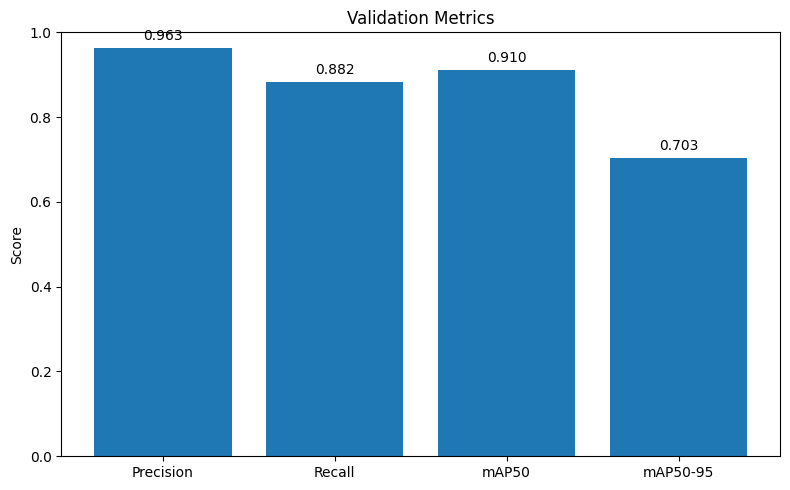

In [28]:
import matplotlib.pyplot as plt

# Your validation metrics
names = ["Precision", "Recall", "mAP50", "mAP50-95"]
values = [0.9626, 0.8825, 0.9103, 0.7030]

plt.figure(figsize=(8, 5))
plt.bar(names, values)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Validation Metrics")

# Show values on bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')

plt.tight_layout()

# ✅ Show in notebook
plt.show()

# ✅ Also save (optional but recommended)
plt.savefig("/kaggle/working/validation_metrics.png", dpi=200)
plt.close()


In [30]:
from pathlib import Path
from ultralytics import YOLO

# Correct paths
best_model_path = Path("/kaggle/working/runs/acne_aug_map5095/weights/best.pt")
data_yaml_path = Path("/kaggle/working/acne-augmented-map5095/data.yaml")

best_model = YOLO(str(best_model_path))

conf_values = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70]
rows = []

for conf in conf_values:
    m = best_model.val(
        data=str(data_yaml_path),
        conf=conf,
        iou=0.5,
        split="val",
        plots=False,
        verbose=False
    )

    p = float(m.box.mp)
    r = float(m.box.mr)
    f1 = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0

    rows.append({
        "conf": conf,
        "precision": p,
        "recall": r,
        "f1": f1
    })

rows = sorted(rows, key=lambda x: x["f1"], reverse=True)

print("Confidence sweep sorted by F1:")
for row in rows:
    print(
        f"conf={row['conf']:.2f}  "
        f"precision={row['precision']:.4f}  "
        f"recall={row['recall']:.4f}  "
        f"f1={row['f1']:.4f}"
    )

best_row = rows[0]

print("\nBest F1 row:")
print(best_row)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1536.3±328.7 MB/s, size: 45.5 KB)
val: Scanning /kaggle/working/acne-augmented-map5095/valid/labels.cache... 106 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 106/106 49.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.0it/s 6.9s1.1ss
                   all        106        434      0.972      0.876      0.874      0.689
Speed: 1.9ms preprocess, 59.9ms inference, 0.0ms loss, 0.5ms postprocess per image
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1248.2±354.4 MB/s, size: 40.5 KB)
val: Scanning /kaggle/working/acne-augmented-map5095/valid/labels.cache... 106 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━

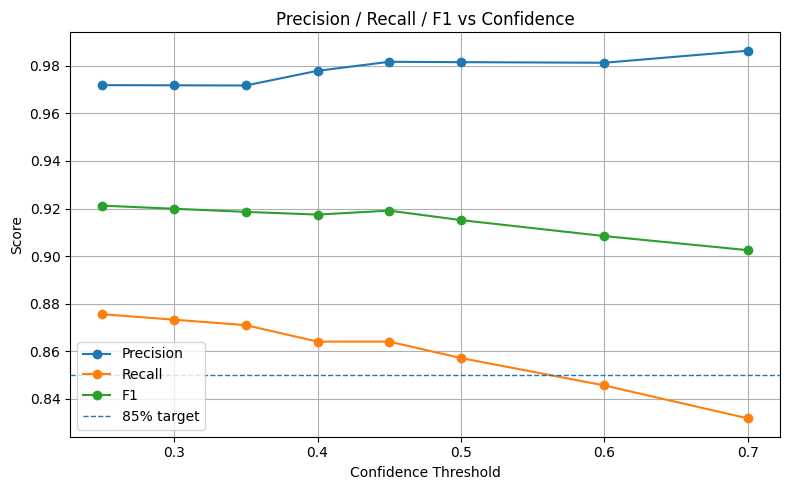

Saved: /kaggle/working/metrics/confidence_curves.png


In [31]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Make sure metrics_dir exists
metrics_dir = Path("/kaggle/working/metrics")
metrics_dir.mkdir(parents=True, exist_ok=True)

# Create dataframe from confidence sweep rows
sweep_df = pd.DataFrame(rows).sort_values("conf").reset_index(drop=True)

plt.figure(figsize=(8, 5))

plt.plot(sweep_df["conf"], sweep_df["precision"], marker="o", label="Precision")
plt.plot(sweep_df["conf"], sweep_df["recall"], marker="o", label="Recall")
plt.plot(sweep_df["conf"], sweep_df["f1"], marker="o", label="F1")

plt.axhline(0.85, linestyle="--", linewidth=1, label="85% target")

plt.xlabel("Confidence Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Confidence")
plt.legend()
plt.grid(True)
plt.tight_layout()

plot_file = metrics_dir / "confidence_curves.png"
plt.savefig(plot_file, dpi=160)
plt.show()

print(f"Saved: {plot_file}")

In [33]:
import json
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("/kaggle/working")
metrics_dir = PROJECT_ROOT / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

run_name = "acne_aug_map5095"
best_weights = Path("/kaggle/working/runs/acne_aug_map5095/weights/best.pt")

if "rows" not in globals() or len(rows) == 0:
    raise RuntimeError("Run the confidence sweep cell first so metrics can be exported.")

sweep_df = pd.DataFrame(rows).sort_values("conf").reset_index(drop=True)

idx = int(sweep_df["f1"].idxmax())
best_row = sweep_df.iloc[idx].to_dict()

summary = {
    "run_name": run_name,
    "best_weights": str(best_weights),

    "default_precision": float(metrics_default.box.mp) if "metrics_default" in globals() else None,
    "default_recall": float(metrics_default.box.mr) if "metrics_default" in globals() else None,
    "default_map50": float(metrics_default.box.map50) if "metrics_default" in globals() else None,
    "default_map50_95": float(metrics_default.box.map) if "metrics_default" in globals() else None,

    "selected_conf": float(best_row["conf"]),
    "selected_precision": float(best_row["precision"]),
    "selected_recall": float(best_row["recall"]),
    "selected_f1": float(best_row["f1"]),

    "target_precision": 0.85,
    "target_recall": 0.85,
    "pass_target": bool(
        best_row["precision"] >= 0.85 and best_row["recall"] >= 0.85
    ),
}

sweep_csv = metrics_dir / "confidence_sweep_metrics.csv"
summary_json = metrics_dir / "metrics_summary.json"

sweep_df.to_csv(sweep_csv, index=False)

with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"Saved: {sweep_csv}")
print(f"Saved: {summary_json}")

print("\nMetric summary:")
for k, v in summary.items():
    print(f"- {k}: {v}")

Saved: /kaggle/working/metrics/confidence_sweep_metrics.csv
Saved: /kaggle/working/metrics/metrics_summary.json

Metric summary:
- run_name: acne_aug_map5095
- best_weights: /kaggle/working/runs/acne_aug_map5095/weights/best.pt
- default_precision: None
- default_recall: None
- default_map50: None
- default_map50_95: None
- selected_conf: 0.25
- selected_precision: 0.9718670076726342
- selected_recall: 0.8755760368663594
- selected_f1: 0.9212121212121211
- target_precision: 0.85
- target_recall: 0.85
- pass_target: True


In [35]:
import shutil
from pathlib import Path

PROJECT_ROOT = Path("/kaggle/working")

models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# Correct path to your trained model
best_weights = Path("/kaggle/working/runs/acne_aug_map5095/weights/best.pt")

# Destination
app_model_path = models_dir / "acne_best.pt"

# Copy model
shutil.copy2(best_weights, app_model_path)

print(f"Copied model for app: {app_model_path}")
print(f"File size (MB): {app_model_path.stat().st_size / (1024 * 1024):.2f}")

Copied model for app: /kaggle/working/models/acne_best.pt
File size (MB): 49.70



image 1/1 /kaggle/working/acne-augmented-map5095/test/images/new_238_jpg.rf.18d3b7ba73d15105e02948704b808407.jpg: 1024x1024 5 items, 67.9ms
Speed: 5.6ms preprocess, 67.9ms inference, 1.3ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /kaggle/working/acne-augmented-map5095/test/images/new_298_jpg.rf.a74b83bf89c2c87c6263a3a89c643783.jpg: 1024x1024 2 items, 50.6ms
Speed: 4.8ms preprocess, 50.6ms inference, 1.4ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /kaggle/working/acne-augmented-map5095/test/images/new_126_jpg.rf.9304c836c516b694b0443495949549f3.jpg: 1024x1024 1 item, 50.1ms
Speed: 5.2ms preprocess, 50.1ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /kaggle/working/acne-augmented-map5095/test/images/new_255_jpg.rf.e18ab402ee5ec58250c215f0def89f45.jpg: 1024x1024 (no detections), 47.9ms
Speed: 4.9ms preprocess, 47.9ms inference, 0.6ms postprocess per image at shape (1, 3, 1024, 1024)


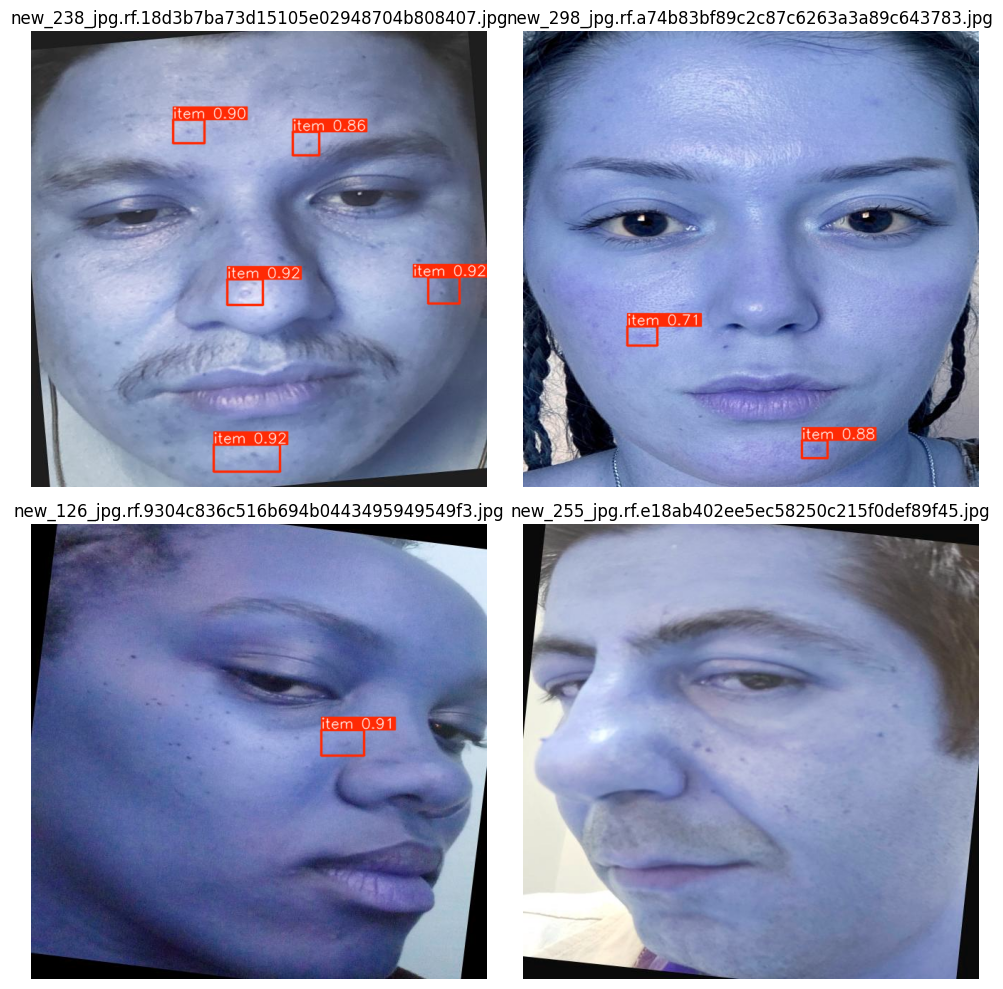

In [37]:
import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

# Paths
model_path = "/kaggle/working/models/acne_best.pt"
test_images_dir = Path("/kaggle/working/acne-augmented-map5095/test/images")

# Load model
model = YOLO(model_path)

# Get images
image_list = list(test_images_dir.glob("*"))
sample_images = random.sample(image_list, min(4, len(image_list)))

# Plot
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, img_path in enumerate(sample_images):
    results = model.predict(
        source=str(img_path),
        imgsz=1024,
        save=False
    )

    # Get plotted image with boxes
    plotted_img = results[0].plot()

    ax = axes[i]
    ax.imshow(plotted_img)
    ax.set_title(img_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [40]:
import shutil
from pathlib import Path

PROJECT_ROOT = Path("/kaggle/working")

zip_path = PROJECT_ROOT / "acne_project_results.zip"

# Remove old zip if exists
if zip_path.exists():
    zip_path.unlink()

# Create zip (NO "with")
archive_path = shutil.make_archive(
    base_name=str(zip_path).replace(".zip", ""),
    format="zip",
    root_dir=PROJECT_ROOT,
    base_dir="."
)

print(f"Saved zip: {archive_path}")

Saved zip: /kaggle/working/acne_project_results.zip
